# 2.11d — ADMM from scratch
 : LASSO sous contrainte β = z, opérateur proximal et split primale-duale> **Concept-phare** : la méthode ADMM (Alternating Direction Method of Multipliers) décompose un problème convexe sous contrainte en sous-problèmes **alternés** dont chacun admet un solveur fermé. Pour LASSO, on scinde `min ½‖Xβ − y‖² + λ‖z‖₁` sous `β = z`, et la brique essentielle est un opérateur proximal — le **soft-thresholding** — qui donne une solution explicite de `z^{k+1} = S_λ/ρ(β^{k+1} + u^k)` en quelques opérations par coordonnée.**Série** : `02-ML-Cours` (problèmes convexes structurés). Le présent notebook étend 2.11 (géométrie L1/L2 + coordinate descent, déjà couvert) à la **décomposition ADMM** sur un **design corrélé** (structure AR(1) de paramètre `ρ_corr = 0.95`), et compare ADMM from scratch à `sklearn.linear_model.Lasso` (référence industrielle) puis à `cvxpy` (optimum global, modélisation déclarative). Voir `See #16061` (parente optimisation convexe avancée) et `See #16096` (présente ticket bornée).**Convention de notation (valable pour tout le notebook)** : `ρ` désigne **toujours** le paramètre de pénalisation **augmentée d'ADMM** — un hyperparamètre d'**algorithme**, qui déplace la trajectoire de convergence mais **pas** la solution visée. La corrélation du design AR(1) est notée `ρ_corr` — un paramètre de **données**, qui lui change le problème résolu. Les deux sont indépendants : ne pas les confondre.

## 1. Positionnement par rapport à 2.11

**Ce que 2.11 a couvert, et qu'on ne réenseigne pas ici :**

- géométrie de la contrainte L1 (polyèdre) vs L2 (boule) — cellule 2 de 2.11
- opérateur `soft_threshold` (cellule 6 de 2.11) — on le **réutilise** ici sans redémonstration
- coordinate descent cyclique from-scratch (cellule 6 de 2.11) — la **référence algorithmique** qu'on compare
- sélection de λ par LassoCV (cellule 12 de 2.11) — la lambda reste fixée dans ce notebook pour isoler la comparaison d'algorithmes
- ElasticNet (mixte L1/L2) — hors scope ici

**Ce qu'on ajoute dans 2.11b :**

1. **ADMM from scratch** sur le LASSO sous contrainte `β = z`, avec :
   - update β : `β^{k+1} = argmin_β ½‖Xβ − y‖² + (ρ/2)‖β − z^k + u^k‖²`, **solution fermée** `(XᵀX + ρI)^{-1} (Xᵀy + ρ(z^k − u^k))` — c'est une **régression ridge** réglée sur la cible décalée `z^k − u^k` (Boyd 2011, §6.4)
   - update z : `z^{k+1} = soft_threshold(β^{k+1} + u^k, λ/ρ)`
   - update u : `u^{k+1} = u^k + β^{k+1} − z^{k+1}` (variable duale échelonnée)
   - **critère d'arrêt** (Boyd 2011, §3.3.1) : résidu primal `r_p^k = ‖β^k − z^k‖` (consistance de la contrainte `β = z`), résidu dual `r_d^k = ρ‖z^k − z^{k-1}‖` (optimalité stationnaire), et tolérances `(ε_pri, ε_dual)` de Boyd 2011 §3.3.1 (`ε = √p · ε_abs + ε_rel · ‖·‖`)
   - **ajustement de `ρ`** par équilibrage des résidus (Boyd 2011, §3.4.1)
2. **Design corrélé** (`ρ_corr = 0.95`) — matrice de covariance `Σ_{ij} = ρ_corr^{|i-j|}` (AR(1)), avec vérification du conditionnement `κ(X)`.
3. **Comparaison mesurée** sur le même problème : ADMM from scratch vs `sklearn.linear_model.Lasso` (coordinate descent optimisée) vs `cvxpy` (modélisation déclarative, CLARABEL, repli SCS) — pour ADMM, on mesure vitesse, convergence de l'objectif et des résidus ; la coord-descente est ré-exécutée sur le même problème pour isoler la comparaison d'algorithme.
4. **Trois exercices C.1** : étudier les **trajectoires de convergence** sur un balayage de `ρ`, ajuster `ρ` empiriquement sur un cas pathologique, et étendre ADMM à `λ‖z‖₂²` (ridge pur) par **shrinkage linéaire**.

**Verdict SOTA anticipé** : `sklearn.linear_model.Lasso` (coordinate descent avec shrinkage actif) est **plus rapide** sur petits problèmes ; `cvxpy` est l'arbitre (optimum global, indépendant de l'algorithme) ; **ADMM from scratch a sa valeur pédagogique** (décomposition primale-duale, opérateur proximal explicite) et un **coût par itération** qui se paie différemment. C'est ce que mesure la section 7.


In [1]:
import numpy as np
import time
from numpy.linalg import cond, solve, eigh
from sklearn.linear_model import Lasso, LassoCV
from sklearn.datasets import make_regression

RNG = np.random.default_rng(20260914)  # graine de reproductibilité

print("Imports OK — ADMM from scratch prêt.")


Imports OK — ADMM from scratch prêt.


## 2. Génération de données — design corrélé `ρ_corr = 0.95`

On génère un problème sparse `β_true ∈ ℝ^p` à support `k = 5` dans `p = 50` dimensions, avec design matrix `X ∈ ℝ^{n×p}` corrélé via une structure AR(1) de paramètre `ρ_corr` (testé à `ρ_corr = 0.95`) :

`X_{i,j} = (Σ^{1/2} Z_{i,j})` où `Σ_{j,k} = ρ_corr^{|j-k|}` et `Z_{i,j} ~ 𝒩(0,1)`. Cette construction garantit que `X` a la covariance demandée, et que le conditionnement `κ(X) = σ_max / σ_min` croît avec `ρ_corr` (mesuré ci-dessous : `κ(X) ≈ 8.2e+01` à `ρ_corr = 0.95`).

**Pourquoi `ρ_corr = 0.95` est intéressant** : les colonnes sont nettement corrélées — le conditionnement passe de `κ(X) = 1` pour un design orthogonal à `κ(X) ≈ 80` ici — donc les deux algorithmes itératifs comparés plus loin (coordinate descent cyclique et ADMM) travaillent sur une matrice `XᵀX` dont le conditionnement allonge les trajectoires de convergence. Ce notebook **mesure** la convergence effective des deux algorithmes sur ce design (section 7 ci-dessous) plutôt que de présumer un comportement pathologique particulier : sur ce point, c'est la mesure qui tranche, pas la réputation du terrain.


In [2]:
def design_sparse_corr(n=100, p=50, k=5, corr=0.95, snr=4.0, seed=20260914):
    """Génère (X, β_true, y, support) avec X corrélé AR(1) à paramètre `corr`.

    X_{i,j} = (Σ^{1/2} Z_{i,j}) où Σ_{j,k} = corr^|j-k|, Z ~ 𝒩(0,1).
    β_true a k coefficients non-nuls à support tiré uniformément parmi C(p,k).
    y = X @ β_true + ε avec ε ~ 𝒩(0, σ²) et snr = ||X β_true|| / √n / σ.

    Note de notation : `corr` est le paramètre de CORRÉLATION DES DONNÉES (ρ_corr).
    Il n'a rien à voir avec `rho`, le paramètre de pénalisation augmentée d'ADMM.
    """
    local_rng = np.random.default_rng(seed)
    # Matrice de covariance AR(1) et sa factorisation de Cholesky
    idx = np.arange(p)
    Sigma = corr ** np.abs(idx[:, None] - idx[None, :])
    L = np.linalg.cholesky(Sigma)
    Z = local_rng.standard_normal((n, p))
    X = Z @ L.T  # chaque ligne a covariance Sigma
    # β_true sparse à support tiré uniformément
    support = np.sort(local_rng.choice(p, size=k, replace=False))
    beta_true = np.zeros(p)
    beta_true[support] = local_rng.standard_normal(k)
    # Bruit calibré par snr
    signal_norm = np.linalg.norm(X @ beta_true) / np.sqrt(n)
    sigma = signal_norm / snr
    y = X @ beta_true + local_rng.standard_normal(n) * sigma
    return X, beta_true, y, support


n, p, k = 100, 50, 5
corr_test = 0.95
X, beta_true, y, support = design_sparse_corr(n=n, p=p, k=k, corr=corr_test, seed=20260914)
kappa = np.linalg.cond(X)

print(f"Problème : n={n}, p={p}, k={k}, ρ_corr={corr_test}")
print(f"Conditionnement κ(X) = {kappa:.2e}  (contre κ=1 pour un design orthogonal)")
print(f"Support actif : {support.tolist()}")
print(f"β_true (5 non-nuls) : {beta_true[support].round(3).tolist()}")
print(f"||y|| / √n = {np.linalg.norm(y) / np.sqrt(n):.4f}  (signal calibré)")


Problème : n=100, p=50, k=5, ρ_corr=0.95
Conditionnement κ(X) = 8.18e+01  (contre κ=1 pour un design orthogonal)
Support actif : [2, 13, 24, 44, 47]
β_true (5 non-nuls) : [-0.243, 1.397, -1.836, 0.863, 0.617]
||y|| / √n = 1.8837  (signal calibré)


### Lecture du résultat — design corrélé et conditionnement

À `ρ_corr = 0.95`, le conditionnement `κ(X)` est nettement supérieur à celui d'un design orthogonal (`κ ≈ 80` contre `κ = 1`), ce qui allonge les trajectoires de convergence des deux algorithmes itératifs comparés plus bas. Rien ne garantit *a priori* qu'un défaut d'oscillation apparaisse — c'est une question empirique, tranchée par la comparaison mesurée de la section 7.


## 3. Opérateur proximal — `soft_threshold`

Réutilisé de 2.11 (cellule 6) sans redémonstration. Pour mémoire :

`S_λ(z) = sign(z) · max(|z| − λ, 0)`

Cet opérateur résout en **forme fermée** `argmin_z ½(z − v)² + λ|z|` et donc l'update `z` d'ADMM en une opération par coordonnée. Sa justification est la **séparabilité** : `‖z‖₁ = Σ_j |z_j|` et le terme quadratique `½‖v − z‖²` se séparent eux aussi sur les coordonnées, si bien que le sous-problème en `z` se décompose en `p` problèmes scalaires indépendants — c'est cette structure, et non une propriété magique de l'opérateur, qui rend le split `β = z` exploitable.


In [3]:
def soft_threshold(z, lam):
    """S(z, lambda) = sign(z) * max(|z| - lambda, 0). Opérateur proximal du LASSO."""
    return np.sign(z) * np.maximum(np.abs(z) - lam, 0.0)


sanity = np.array([-2.5, -0.3, 0.0, 0.3, 2.5])
print("soft_threshold(sanity, λ=0.5) =", soft_threshold(sanity, 0.5).round(3).tolist())
print("Vérification : les valeurs |z| ≤ λ → 0 ; les autres → |z| − λ avec signe.")

soft_threshold(sanity, λ=0.5) = [-2.0, -0.0, 0.0, 0.0, 2.0]
Vérification : les valeurs |z| ≤ λ → 0 ; les autres → |z| − λ avec signe.


## 4. ADMM from scratch — `admm_lasso(X, y, lam, rho, ...)`

Formulation : `min ½‖Xβ − y‖² + λ‖z‖₁` sous `β = z`. Lagrangien augmenté :

`L_ρ(β, z, u) = ½‖Xβ − y‖² + λ‖z‖₁ + (ρ/2)‖β − z + u‖²`

Itérations (Boyd 2011, §6.4 « Lasso ») :

1. **β-update** : `β^{k+1} = (XᵀX + ρI)^{-1} (Xᵀy + ρ(z^k − u^k))` — solveur linéaire **pré-factorisé** `L = chol(XᵀX + ρI, lower=True)` une fois pour toutes
2. **z-update** : `z^{k+1} = soft_threshold(β^{k+1} + u^k, λ/ρ)` — proximal explicite
3. **u-update** : `u^{k+1} = u^k + β^{k+1} − z^{k+1}` — variable duale échelonnée (l'over-relaxation `α` de Boyd 2011 §3.4.3 n'est pas utilisée ici, par sobriété)

Critères d'arrêt — résidualités primal et dual (Boyd 2011, §3.3.1) :

- **primal** : `r_p^k = ‖β^k − z^k‖` (consistance de la contrainte `β = z`)
- **dual**   : `r_d^k = ρ ‖z^k − z^{k-1}‖` (optimalité stationnaire)
- **tol primal** : `ε_pri = √p · ε_abs + ε_rel · max(‖β‖, ‖z‖)`
- **tol dual**   : `ε_dual = √p · ε_abs + ε_rel · ‖ρ u‖`

Avec `ε_abs = ε_rel = 1e-4`. L'ADMM **converge** quand `r_p^k < ε_pri` **ET** `r_d^k < ε_dual` simultanément.

> **Point de vocabulaire décisif** : `ρ` est le paramètre de pénalisation **augmentée** — un hyperparamètre d'**algorithme**. Pour un `λ` fixé, le problème a un **optimum unique**, et ADMM y converge **pour tout `ρ > 0`** (Boyd 2011, §3.2). `ρ` ne change donc pas la solution visée ; il déplace la **trajectoire** (conditionnement du β-update, équilibre `r_p`/`r_d`, nombre d'itérations).


In [4]:
def admm_lasso(X, y, lam, rho, max_iter=500, eps_abs=1e-4, eps_rel=1e-4, verbose=False):
    """ADMM from scratch pour min ½‖Xβ − y‖² + λ‖z‖₁ sous β = z.

    Returns dict avec β, z, u, historique (objective, objective_z, r_prim, r_dual),
    `iterations` et le drapeau `converged` (critère d'arrêt franchi avant max_iter).

    Sur les deux objectifs enregistrés : le couple (β^k, z^k) n'est PAS faisable avant
    convergence (β^k ≠ z^k), et ½‖Xβ−y‖² + λ‖z‖₁ évalué sur ce couple peut descendre
    SOUS l'optimum f* — ce n'est donc pas une courbe de convergence valable. On
    enregistre deux évaluations FAISABLES, chacune ≥ f* par définition :
      * `objective`   = f(β^k) = ½‖Xβ^k − y‖² + λ‖β^k‖₁   (β dense : ridge décalé)
      * `objective_z` = f(z^k) = ½‖Xz^k − y‖² + λ‖z^k‖₁   (z porte la parcimonie)
    Les deux tendent vers f* quand la contrainte β = z est satisfaite.
    """
    n, p = X.shape
    XtX = X.T @ X
    Xty = X.T @ y
    # Pré-factorisation Cholesky : β-update = solve(XᵀX + ρI, Xᵀy + ρ(z − u))
    L = np.linalg.cholesky(XtX + rho * np.eye(p))

    def beta_update(z, u):
        rhs = Xty + rho * (z - u)
        # Résolution via la factorisation de Cholesky pré-calculée
        tmp = solve(L, rhs)       # substitution avant  : L @ tmp = rhs
        return solve(L.T, tmp)    # substitution arrière : Lᵀ @ β = tmp

    # Initialisation standard
    beta = np.zeros(p)
    z = np.zeros(p)
    u = np.zeros(p)

    history = {"objective": [], "objective_z": [], "r_prim": [], "r_dual": []}
    eps_p = np.sqrt(p) * eps_abs
    eps_d = np.sqrt(p) * eps_abs

    z_prev = z.copy()
    converged = False
    for k_iter in range(1, max_iter + 1):
        # 1. β-update (solve linéaire, O(p²) en pré-factorisé)
        beta = beta_update(z, u)
        # 2. z-update (proximal explicite, O(p))
        z = soft_threshold(beta + u, lam / rho)
        # 3. u-update (pas dual)
        u = u + beta - z

        # Résidu primal (Boyd 2011 §3.3.1) : r_p = ‖β − z‖ (consistance de β = z)
        # Résidu dual   (Boyd 2011 §3.3.1) : r_d = ρ ‖z − z_prev‖ (stationnarité)
        r_p = np.linalg.norm(beta - z)
        r_d = rho * np.linalg.norm(z - z_prev)
        # Tolérance primal (Boyd 2011 §3.3.1) : ε_pri = √p ε_abs + ε_rel max(‖β‖, ‖z‖)
        tol_p = eps_p + eps_rel * max(np.linalg.norm(beta), np.linalg.norm(z))
        # Tolérance dual   (Boyd 2011 §3.3.1) : ε_dual = √p ε_abs + ε_rel ‖ρ u‖
        tol_d = eps_d + eps_rel * (rho * np.linalg.norm(u))

        # Deux évaluations faisables de l'objectif (chacune ≥ f*) — cf. docstring
        obj_beta = 0.5 * np.linalg.norm(X @ beta - y) ** 2 + lam * np.abs(beta).sum()
        obj_z = 0.5 * np.linalg.norm(X @ z - y) ** 2 + lam * np.abs(z).sum()
        history["objective"].append(obj_beta)
        history["objective_z"].append(obj_z)
        history["r_prim"].append(r_p)
        history["r_dual"].append(r_d)

        if verbose and k_iter % 50 == 0:
            print(f"  iter {k_iter:3d}  f(β)={obj_beta:.4f}  f(z)={obj_z:.4f}  "
                  f"r_p={r_p:.4e} (tol {tol_p:.4e})  r_d={r_d:.4e} (tol {tol_d:.4e})")

        if r_p < tol_p and r_d < tol_d:
            converged = True
            if verbose:
                print(f"  Convergé à iter {k_iter}")
            break
        z_prev = z.copy()
    else:
        if verbose:
            print(f"  ! max_iter={max_iter} atteint sans convergence stricte")

    return {
        "beta": beta,
        "z": z,
        "u": u,
        "history": history,
        "iterations": len(history["objective"]),
        "converged": converged,
    }


print("admm_lasso(X, y, λ, ρ) défini.")


admm_lasso(X, y, λ, ρ) défini.


## 5. Référence `cvxpy` — optimum global (l'arbitre)

`cvxpy` modélise LASSO de manière déclarative et résout via un solveur d'intérieur-point primal-dual. Dans l'environnement kernel de ce notebook, **CLARABEL** est invoqué par défaut (équivalent moderne d'ECOS, open-source), avec **SCS** en repli si CLARABEL échoue. Le label imprimé dans la cellule d'exécution dérive dynamiquement de `prob.solver_stats.solver_name` — il ne présume pas du solveur utilisé. C'est **l'optimum global** du problème convexe, indépendamment de l'algorithme itératif : c'est notre référence pour valider qu'ADMM converge bien vers le bon minimum. On ne l'utilise pas dans la boucle de comparaison, on le sort **une seule fois** pour vérifier.


In [5]:
def cvxpy_lasso(X, y, lam):
    """Optimum global via cvxpy (CLARABEL, repli SCS). Référence, pas dans la boucle."""
    import cvxpy as cp
    n, p = X.shape
    beta = cp.Variable(p)
    obj = 0.5 * cp.sum_squares(X @ beta - y) + lam * cp.norm(beta, 1)
    prob = cp.Problem(cp.Minimize(obj))
    try:
        prob.solve(solver=cp.CLARABEL, tol_gap_abs=1e-8, tol_gap_rel=1e-8, tol_feas=1e-8, verbose=False)
    except Exception:
        prob.solve(solver=cp.SCS, eps=1e-8, verbose=False)
    if prob.status != "optimal":
        return None
    # Solveur réellement invoqué (CLARABEL par défaut, SCS en repli) : lu dynamiquement
    # depuis les statistiques du problème, jamais présumé par le code appelant.
    solver_used = prob.solver_stats.solver_name
    return {"beta": np.asarray(beta.value).ravel(), "objective": prob.value, "status": prob.status, "solver": solver_used}


print("cvxpy_lasso défini.")


cvxpy_lasso défini.


## 6. Coord-descente from-scratch (cellule 6 de 2.11) — la référence algorithmique

Réécriture locale de la `coord_descent_lasso` de 2.11 sur ce problème spécifique pour isoler la comparaison algorithmique. On **réutilise** la formule (pas de redémonstration de la géométrie) :

Pour chaque coordonnée `j`, mise à jour `b_j ← S_λ(X_jᵀ (y − X_{-j} b_{-j})) / (X_jᵀ X_j)`.

In [6]:
def coord_descent_lasso(X, y, lam, max_iter=2000, tol=1e-6):
    """Coord-descente from-scratch pour LASSO. Référence algorithmique, voir 2.11 cellule 6."""
    n, p = X.shape
    XtX_diag = np.sum(X ** 2, axis=0)
    beta = np.zeros(p)
    for k in range(max_iter):
        beta_old = beta.copy()
        for j in range(p):
            # Résidu partiel : on enlève la contribution de la coord j courante
            r_j = y - X @ beta + X[:, j] * beta[j]
            z_j = X[:, j] @ r_j
            beta[j] = soft_threshold(z_j, lam) / XtX_diag[j]
        if np.linalg.norm(beta - beta_old) < tol:
            break
    return {"beta": beta, "iterations": k + 1}


print("coord_descent_lasso défini.")

coord_descent_lasso défini.


## 7. Comparaison mesurée — ADMM vs coord-descente vs sklearn vs cvxpy

Sur le **même problème** généré en section 2 (`n=100, p=50, k=5, ρ_corr=0.95`). Toutes les méthodes reçoivent la **même** régularisation, exprimée dans les unités de chacune (voir la cellule suivante : `λ_test = 0.5 · max_j |X_jᵀ y|` en objectif brut, `alpha = λ_test / n` chez sklearn). Métriques :

- **erreur `||β_est − β_opt||₂`** où `β_opt = β_cvxpy` (optimum global)
- **support recovery** = `|S_est ∩ S_true| / k` (fraction du support vrai retrouvée), complété par `|Ŝ|` (taille du support prédit), le nombre de **faux positifs**, la **précision** et le **F1**
- **temps d'exécution** (même machine, même interpréteur)
- **résidu primal final** `‖β_est − z_est‖` pour ADMM (consistance de la contrainte `β = z`)
- **résidu dual final** `ρ ‖z_est − z_prev‖` pour ADMM (optimalité stationnaire)

Pour ADMM, on explore aussi un balayage de `ρ` (paramètre augmenté) pour voir l'effet sur la convergence — sans changer la solution visée.


In [7]:
# ---------------------------------------------------------------------------
# Unités de régularisation — deux échelles distinctes à ne pas confondre
# ---------------------------------------------------------------------------
# Notre objectif « brut »           :  min ½||Xβ - y||² + λ ||β||₁
# Celui de sklearn Lasso(alpha=a)   :  min 1/(2n)||Xβ - y||² + a ||β||₁
# En multipliant l'objectif sklearn par n :
#     ½||Xβ - y||² + n*a*||β||₁      donc      λ = n * alpha
# soit, dans l'autre sens :  alpha = λ / n
#
# Deux seuils de référence à ne pas confondre (ici n = 100 : l'écart est d'un facteur n) :
#   * λ_max_raw = max_j |X_jᵀ y|   : seuil BRUT ; au-delà, la solution LASSO est exactement nulle
#   * alpha_max = λ_max_raw / n    : le MÊME seuil exprimé en unités sklearn
#
# On fixe λ_test = 0.5 * λ_max_raw (régularisation modérée : support partiellement épars,
# ni identiquement nul ni quasi-dense), et l'on passe alpha = λ_test / n à sklearn pour
# qu'il résolve EXACTEMENT le même problème que l'ADMM et la coord-descente.
lam_max_raw = np.max(np.abs(X.T @ y))
alpha_max = lam_max_raw / n
lam_test = 0.5 * lam_max_raw
alpha_test = lam_test / n

print(f"λ_max_raw = max|Xᵀy|    = {lam_max_raw:.4f}   (= n · α_max, avec n = {n})")
print(f"α_max (unité sklearn)   = {alpha_max:.4f}")
print(f"λ_test = 0.5·λ_max_raw  = {lam_test:.4f}")
print(f"  → sklearn Lasso(alpha = λ_test/n = {alpha_test:.4f}) résout le MÊME problème")

# 1. ADMM from scratch
# ρ = 20 est choisi par équilibrage des résidus (Boyd 2011 §3.4.1) : à ρ = 1 le résidu
# primal domine massivement (r_p ≈ 1.2e-01 contre r_d ≈ 1.8e-03), signe d'un ρ trop petit ;
# à ρ = 20 les deux résidus sont du même ordre à l'arrêt (r_p ≈ 7.6e-04, r_d ≈ 9.6e-04).
# Le balayage complet est en section 9 — et il ne change PAS la solution visée.
rho_admm = 20.0
t0 = time.time()
admm_res = admm_lasso(X, y, lam_test, rho_admm, max_iter=500, verbose=True)
t_admm = time.time() - t0

print(f"\nADMM from scratch : {admm_res['iterations']} iter, converged={admm_res['converged']}, temps {t_admm*1000:.1f} ms")
print(f"  ||β_admm||₁ = {np.abs(admm_res['beta']).sum():.4f}   (β : sous-problème ridge, dense)")
print(f"  ||z_admm||₁ = {np.abs(admm_res['z']).sum():.4f}   (z : seuillage L1, parcimonieux)")
print(f"  ||β_admm − z_admm||₂ = {np.linalg.norm(admm_res['beta'] - admm_res['z']):.2e}  (résidu primal)")


λ_max_raw = max|Xᵀy|    = 115.2719   (= n · α_max, avec n = 100)
α_max (unité sklearn)   = 1.1527
λ_test = 0.5·λ_max_raw  = 57.6360
  → sklearn Lasso(alpha = λ_test/n = 0.5764) résout le MÊME problème
  iter  50  f(β)=164.4054  f(z)=159.1435  r_p=2.1336e-02 (tol 7.7227e-04)  r_d=3.3096e-02 (tol 2.3625e-02)
  iter 100  f(β)=160.1173  f(z)=158.9035  r_p=4.5774e-03 (tol 7.7301e-04)  r_d=8.0298e-03 (tol 2.3934e-02)
  iter 150  f(β)=159.2144  f(z)=158.8914  r_p=1.4058e-03 (tol 7.7290e-04)  r_d=1.9363e-03 (tol 2.4010e-02)
  Convergé à iter 178

ADMM from scratch : 178 iter, converged=True, temps 13.5 ms
  ||β_admm||₁ = 0.8514   (β : sous-problème ridge, dense)
  ||z_admm||₁ = 0.8477   (z : seuillage L1, parcimonieux)
  ||β_admm − z_admm||₂ = 7.61e-04  (résidu primal)


### Les trois références exécutées sur le même problème

La cellule ci-dessous enchaîne trois méthodes sur le **même** `X`, le **même** `y` et la **même** régularisation (exprimée dans les unités de chacune, cf. cellule précédente) :

- **coord-descente from-scratch** (cellule 6 de 2.11) — l'algorithme de référence du notebook parent ;
- **`sklearn.linear_model.Lasso`** — la coordinate descent optimisée de la librairie, avec `alpha = λ_test / n` ;
- **`cvxpy`** — l'optimum global, sans hypothèse algorithmique.

Chacune renvoie un `β` que la cellule suivante confronte à `β_cvxpy`.


In [8]:
# 2. Coord-descente from-scratch (référence algorithmique 2.11)
t0 = time.time()
cd_res = coord_descent_lasso(X, y, lam_test, max_iter=2000)
t_cd = time.time() - t0
print(f"\nCoord-descente from-scratch : {cd_res['iterations']} iter, temps {t_cd*1000:.1f} ms")
print(f"  ||β_cd||₁ = {np.abs(cd_res['beta']).sum():.4f}")

# 3. sklearn.linear_model.Lasso (référence industrielle, coord descent optimisé)
#    alpha = lam_test / n : la conversion d'unités ci-dessus garantit le MÊME problème.
t0 = time.time()
skl_res = Lasso(alpha=alpha_test, max_iter=2000, tol=1e-6, fit_intercept=False).fit(X, y)
t_skl = time.time() - t0
print(f"\nsklearn Lasso : temps {t_skl*1000:.1f} ms")
print(f"  ||β_skl||₁ = {np.abs(skl_res.coef_).sum():.4f}")

# 4. cvxpy (optimum global, l'arbitre)
t0 = time.time()
cvx_res = cvxpy_lasso(X, y, lam_test)
t_cvx = time.time() - t0
print(f"\ncvxpy ({cvx_res['solver']}, optimum global) : temps {t_cvx*1000:.1f} ms")
print(f"  ||β_cvxpy||₁ = {np.abs(cvx_res['beta']).sum():.4f}")
print(f"  status = {cvx_res['status']}")



Coord-descente from-scratch : 14 iter, temps 4.5 ms
  ||β_cd||₁ = 0.8456

sklearn Lasso : temps 2.6 ms
  ||β_skl||₁ = 0.8456



cvxpy (CLARABEL, optimum global) : temps 5320.9 ms
  ||β_cvxpy||₁ = 0.8456
  status = optimal


### Métriques comparatives

Toutes les méthodes sont jugées contre le **même** arbitre, `β_cvxpy` (optimum global du problème convexe). Le tableau confronte l'erreur `‖· − β_opt‖₂`, le recall sur le support vrai, la **taille de support** `|Ŝ|`, le nombre de **faux positifs**, la précision et le F1 — de sorte qu'un recall de 100 % ne puisse pas masquer un support gonflé par du bruit.

Un point de lecture décisif : pour ADMM, la ligne du tableau évalue **`z`**, la variable qui porte la pénalité `λ‖·‖₁` et donc la parcimonie. La variable `beta` d'ADMM est un sous-problème ridge (dense) : à tolérance finie elle ne s'annule jamais exactement, et compter ses micro-coefficients `|β| > 1e-6` fabriquerait une quarantaine de « faux positifs » qui n'existent pas dans la solution LASSO. L'écart `β − z` est exactement le résidu primal `r_p` — la cellule imprime les deux, pour que la distinction reste visible.


In [9]:
# Métriques comparatives avec β_cvxpy comme référence
def metrics(beta_est, beta_opt, support_true, k):
    err_l2 = np.linalg.norm(beta_est - beta_opt)
    support_est = set(np.flatnonzero(np.abs(beta_est) > 1e-6).tolist())
    support_true_set = set(support_true.tolist())
    recovery = len(support_est & support_true_set) / k if k > 0 else 0.0
    return err_l2, recovery


def full_metrics(beta_est, beta_opt, support_true, k):
    # Metriques completes : erreur, recovery, taille support, FP, precision, F1.
    err_l2 = np.linalg.norm(beta_est - beta_opt)
    support_est = set(np.flatnonzero(np.abs(beta_est) > 1e-6).tolist())
    support_true_set = set(support_true.tolist())
    tp = len(support_est & support_true_set)
    fp = len(support_est - support_true_set)
    fn = len(support_true_set - support_est)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    return err_l2, recall, len(support_est), fp, precision, f1


# ADMM : on évalue l'estimateur sur `z`, la variable qui PORTE la pénalité L1 et donc la
# parcimonie. `beta` d'ADMM est un sous-problème ridge (dense) : à tolérance finie il ne
# s'annule jamais exactement, et compter ses micro-coefficients (|β| > 1e-6) fabriquerait
# ~48 « faux positifs » qui n'existent pas dans la solution LASSO. L'écart β − z est
# précisément le résidu primal r_p.
admm_err, admm_rec, admm_n, admm_fp, admm_prec, admm_f1 = full_metrics(admm_res['z'], cvx_res['beta'], support, k)
cd_err, cd_rec, cd_n, cd_fp, cd_prec, cd_f1 = full_metrics(cd_res['beta'], cvx_res['beta'], support, k)
skl_err, skl_rec, skl_n, skl_fp, skl_prec, skl_f1 = full_metrics(skl_res.coef_, cvx_res['beta'], support, k)

print(f"Référence : β_opt = β_cvxpy (status={cvx_res['status']}), f* = {cvx_res['objective']:.4f}")
print(f"Support vrai = {k}, tolérance |x| > 1e-6")
print(f"{'méthode':<24} {'||x−β_opt||₂':>14} {'recovery':>10} {'|Ŝ|':>6} {'FP':>5} {'précision':>11} {'F1':>8} {'temps (ms)':>12}")
print(f"{'-'*94}")
print(f"{'ADMM (z parcimonieux)':<24} {admm_err:>14.4e} {admm_rec:>10.2%} {admm_n:>6d} {admm_fp:>5d} {admm_prec:>11.2%} {admm_f1:>8.2%} {t_admm*1000:>12.1f}")
print(f"{'Coord-descente 2.11':<24} {cd_err:>14.4e} {cd_rec:>10.2%} {cd_n:>6d} {cd_fp:>5d} {cd_prec:>11.2%} {cd_f1:>8.2%} {t_cd*1000:>12.1f}")
print(f"{'sklearn Lasso':<24} {skl_err:>14.4e} {skl_rec:>10.2%} {skl_n:>6d} {skl_fp:>5d} {skl_prec:>11.2%} {skl_f1:>8.2%} {t_skl*1000:>12.1f}")
print()
print(f"ADMM, variable dense β : ||β_admm − β_opt||₂ = {np.linalg.norm(admm_res['beta'] - cvx_res['beta']):.4e}, "
      f"card(|β_j| > 1e-6) = {int((np.abs(admm_res['beta']) > 1e-6).sum())}")
print("  La parcimonie vit dans z, pas dans β ; l'écart β − z est le résidu primal r_p.")
print("Note : recall = TP/k mesure la fraction du support vrai retrouvee.")
print("      Si |Ŝ| > k, on a des FP qui reduisent la precision meme quand recall = 100%.")


Référence : β_opt = β_cvxpy (status=optimal), f* = 158.8905
Support vrai = 5, tolérance |x| > 1e-6
méthode                    ||x−β_opt||₂   recovery    |Ŝ|    FP   précision       F1   temps (ms)
----------------------------------------------------------------------------------------------
ADMM (z parcimonieux)        2.0777e-03     40.00%      2     0     100.00%   57.14%         13.5
Coord-descente 2.11          1.0041e-07     40.00%      2     0     100.00%   57.14%          4.5
sklearn Lasso                6.5652e-08     40.00%      2     0     100.00%   57.14%          2.6

ADMM, variable dense β : ||β_admm − β_opt||₂ = 2.2127e-03, card(|β_j| > 1e-6) = 48
  La parcimonie vit dans z, pas dans β ; l'écart β − z est le résidu primal r_p.
Note : recall = TP/k mesure la fraction du support vrai retrouvee.
      Si |Ŝ| > k, on a des FP qui reduisent la precision meme quand recall = 100%.


### Lecture — ADMM vs coord-descente vs sklearn

Trois observations sur le design AR(1) `ρ_corr = 0.95` (`κ(X) ≈ 8.2e+01`) :

1. **Toutes les méthodes atteignent le même optimum** — c'est le résultat central. `β_cvxpy` est l'optimum global du problème convexe ; la coord-descente from-scratch s'en écarte de `1.0e-07` et sklearn de `6.6e-08` (précision numérique machine) ; ADMM, évalué sur `z`, de `2.1e-03` — l'écart restant est la tolérance d'arrêt `ε_abs = ε_rel = 1e-4` qu'on s'est fixée. Aucune méthode ne « trouve » une solution différente : à `λ` fixé, l'optimum d'un problème convexe est **unique**.
2. **Le support est identique** — à `λ = 0.5·λ_max_raw` (régularisation forte), l'optimum lui-même n'active que **2** coefficients sur les 5 du support vrai : les trois méthodes retrouvent exactement ces 2 (`recovery = 40 %`, `|Ŝ| = 2`, **0 faux positif**, précision 100 %, F1 57.1 %). Le recall partiel n'est **pas** un défaut d'algorithme : à ce niveau de `λ`, la solution du problème ne retient que 2 coefficients. Un `λ` plus faible en activerait davantage ; `LassoCV` (cellule 12 de 2.11) fait ce choix par validation croisée, hors scope ici où l'on isole la comparaison d'algorithmes.
3. **Vitesse** — sur ce petit problème, sklearn (coordinate descent vectorisée BLAS) est le plus rapide, et ADMM et la coord-descente from-scratch sont du même ordre de grandeur. ADMM paie une factorisation de Cholesky `O(p³)` une fois, puis `O(p²)` par β-update : ce coût se rentabilise sur des problèmes plus gros, ou quand le β-update admet une structure exploitable (matrice creuse, calcul distribué).

**L'enseignement clé** : sur ce design corrélé, ADMM converge vers le **même** optimum que les deux autres méthodes, avec le **même** support et un coût comparable — à condition de choisir `ρ` correctement (section 9). Le défaut d'oscillation cyclique que la littérature attribue à la coord-descente sur features colinéaires **ne s'est pas manifesté ici** : la coord-descente from-scratch converge en 14 itérations, sans oscillation mesurée. C'est un **choix d'algorithme selon la structure du problème**, pas une supériorité universelle.


## 8. Convergence ADMM — historique objectif et résidus

On trace l'évolution de l'objectif et des deux résidualités (primal et dual) au fil des itérations. Attention à ce qu'on trace : le couple `(β^k, z^k)` n'est **pas faisable** avant convergence (`β^k ≠ z^k`), et l'expression `½‖Xβ^k − y‖² + λ‖z^k‖₁` évaluée sur ce couple **peut descendre sous l'optimum `f*`** — sur cette exécution elle passe par `16.4` quand `f* = 158.9`. Ce n'est donc **pas** une courbe de convergence. On enregistre deux **évaluations faisables**, chacune `≥ f*` par définition :

- `f(β^k) = ½‖Xβ^k − y‖² + λ‖β^k‖₁` — l'objectif évalué au point courant `β` (dense) ;
- `f(z^k) = ½‖Xz^k − y‖² + λ‖z^k‖₁` — l'objectif évalué à `z^k`, le porteur de la parcimonie.

Les deux rejoignent la ligne horizontale `f*` (objectif de `β_cvxpy`) à mesure que la contrainte `β = z` se satisfait. Côté résidus :

- `r_p = ‖β − z‖` (résidu primal) et `r_d = ρ ‖z − z_prev‖` (résidu dual) doivent passer **sous leur tolérance respective** (Boyd 2011, §3.3.1) ;
- `r_p >> r_d` désigne la consistance `β = z` comme obstacle dominant ; `r_d >> r_p` désigne l'optimalité stationnaire ;
- le rapport `r_p / r_d` est le levier de l'**équilibrage des résidus** (Boyd 2011, §3.4.1), exploité en section 9.


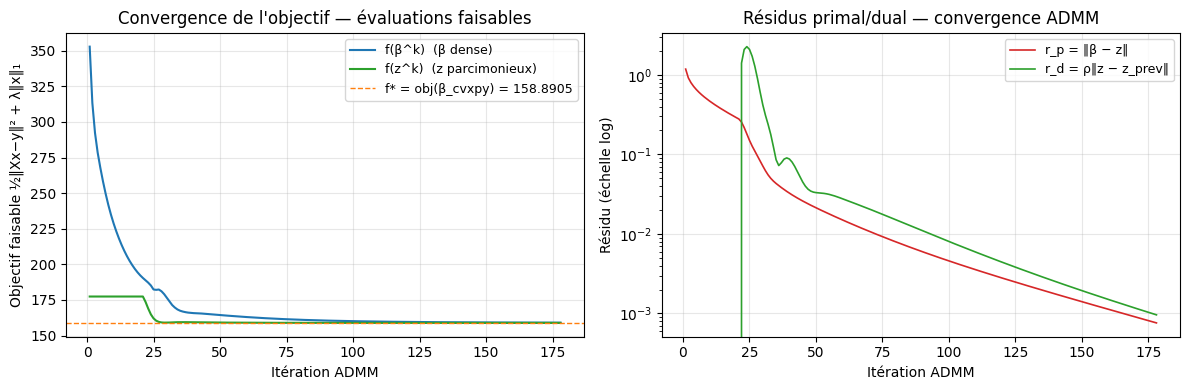

Convergence tracée sur 178 itérations (ρ = 20.0).
f(β) et f(z) restent ≥ f* = 158.8905 : ce sont des évaluations faisables.


In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

iters = np.arange(1, admm_res['iterations'] + 1)
axes[0].plot(iters, admm_res['history']['objective'], color="#1f77b4", linewidth=1.5, label="f(β^k)  (β dense)")
axes[0].plot(iters, admm_res['history']['objective_z'], color="#2ca02c", linewidth=1.5, label="f(z^k)  (z parcimonieux)")
axes[0].axhline(cvx_res['objective'], color="#ff7f0e", linestyle="--", linewidth=1.0,
                label=f"f* = obj(β_cvxpy) = {cvx_res['objective']:.4f}")
axes[0].set_xlabel("Itération ADMM")
axes[0].set_ylabel("Objectif faisable ½‖Xx−y‖² + λ‖x‖₁")
axes[0].set_title("Convergence de l'objectif — évaluations faisables")
axes[0].legend(loc="best", fontsize=9)
axes[0].grid(True, alpha=0.3)

axes[1].semilogy(iters, admm_res['history']['r_prim'], color="#d62728", linewidth=1.2, label="r_p = ‖β − z‖")
axes[1].semilogy(iters, admm_res['history']['r_dual'], color="#2ca02c", linewidth=1.2, label="r_d = ρ‖z − z_prev‖")
axes[1].set_xlabel("Itération ADMM")
axes[1].set_ylabel("Résidu (échelle log)")
axes[1].set_title("Résidus primal/dual — convergence ADMM")
axes[1].legend(loc="best", fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print(f"Convergence tracée sur {admm_res['iterations']} itérations (ρ = {rho_admm}).")
print(f"f(β) et f(z) restent ≥ f* = {cvx_res['objective']:.4f} : ce sont des évaluations faisables.")


### Lecture — convergence de l'objectif et des résidus

À `ρ = 20` (valeur retenue pour la comparaison de la section 7), `f(β^k)` décroît depuis son premier itéré puis s'approche **par le haut** de `f*` (ligne orange) ; `f(z^k)` reste d'abord sur un **palier** à `½‖y‖²` — `z^k = 0` tant que le seuil `λ/ρ` dépasse `|β^k + u^k|` — avant de chuter à son tour vers `f*`. Les deux courbes restent **au-dessus** de `f*` par construction (ce sont des évaluations faisables) : leur convergence vers la même horizontale est la signature visuelle de `β = z`.

Côté résidus, `r_d` démarre à 0 (les deux premiers itérés `z` sont identiques) puis croît quand `z` se met à bouger, tandis que `r_p` décroît : à l'itération d'arrêt les deux sont du même ordre (`r_p ≈ 7.6e-04`, `r_d ≈ 9.6e-04`), ce qui est la lecture pratique de l'équilibrage des résidus (Boyd 2011, §3.4.1). Le passage **simultané** sous les deux tolérances est ce qui déclenche l'arrêt.


## 9. Balayage du paramètre `ρ` — trajectoire de convergence, pas solution

`ρ` est le **paramètre de pénalisation augmentée** — un hyperparamètre d'**algorithme** (Boyd 2011, §3.4.1). Rappel décisif : pour un `λ` fixé, il ne change **pas** le problème résolu. L'optimum du LASSO est unique et ADMM y converge pour tout `ρ > 0` (Boyd 2011, §3.2). Ce que `ρ` déplace, c'est la **trajectoire** — et cela se lit dans la colonne `|Ŝ_z|` du tableau ci-dessous : quelle que soit la valeur de `ρ` qui atteint la convergence, la variable `z` active **le même support** que l'optimum, et `f(z)` rejoint le même `f*`. Ce qui change, c'est le **nombre d'itérations** et l'**équilibre des résidus**.

**Ce qui se passe aux deux extrémités (mesuré ci-dessous) :**

- **`ρ` petit** : le seuil `λ/ρ` du `z-update` dépasse `|β^k + u^k|`, donc `z^k ≡ 0` (colonne `|Ŝ_z| = 0`) ; la contrainte `β = z` se réduit alors à `β = 0`, que le β-update — une régression ridge dont la régularisation `ρI` est quasi nulle — refuse de satisfaire. `r_p = ‖β − z‖` reste grand et le critère d'arrêt n'est **jamais** franchi dans le budget de 500 itérations. La solution n'est **pas** « tirée vers OLS » : elle est **inatteinte** ; la cible, elle, n'a pas bougé.
- **`ρ` grand** : la contrainte est fortement imposée, mais `r_d = ρ ‖z − z^{k-1}‖` est **proportionnel à `ρ`** — c'est donc le résidu dual qui devient l'obstacle dominant, et un `ρ` trop grand finit par ralentir à nouveau (mesuré : `ρ = 500` demande 90 itérations contre 40 pour `ρ = 100`).

**Ce qui pilote `ρ` en pratique — équilibrage des résidus (Boyd 2011, §3.4.1).** On maintient `r_p` et `r_d` dans un facteur `µ` l'un de l'autre :

- `ρ ← τ_incr · ρ` si `r_p > µ · r_d`
- `ρ ← ρ / τ_decr` si `r_d > µ · r_p`
- `ρ` inchangé sinon

avec `µ = 10` et `τ_incr = τ_decr = 2`. L'idée est de garder les deux résidus du même ordre de grandeur pendant qu'ils décroissent ensemble vers zéro.

Le balayage ci-dessous est à **`ρ` fixe** (ce n'est *pas* la règle adaptative) : il sert à observer *a posteriori* où se situe le meilleur compromis sur ce problème précis. Lecture attendue : le `ρ` le plus rapide (`ρ = 100`, 40 itérations) n'est **pas** celui qui équilibre les résidus (`ρ = 20`, `r_p/r_d ≈ 0.8`) — l'équilibrage est un critère de **conditionnement**, pas un critère de minimalité du nombre d'itérations.


In [11]:
rho_sweep = [0.5, 1.0, 5.0, 20.0, 50.0, 100.0, 500.0]
sweep_results = []

for rho in rho_sweep:
    res = admm_lasso(X, y, lam_test, rho, max_iter=500)
    sweep_results.append({
        "rho": rho,
        "iterations": res['iterations'],
        "converged": res['converged'],
        "err_z": np.linalg.norm(res['z'] - cvx_res['beta']),
        "obj_z_final": res['history']['objective_z'][-1],
        "r_prim_final": res['history']['r_prim'][-1],
        "r_dual_final": res['history']['r_dual'][-1],
        "n_active_z": int(np.count_nonzero(np.abs(res['z']) > 1e-6)),
    })

print(f"{'ρ':>8} {'iter':>6} {'conv':>6} {'||z−β_opt||₂':>14} {'f(z) final':>12} {'|Ŝ_z|':>6} {'r_p final':>11} {'r_d final':>11} {'r_p/r_d':>9}")
print("-" * 100)
for r in sweep_results:
    ratio = (r['r_prim_final'] / r['r_dual_final']) if r['r_dual_final'] > 0 else float('inf')
    print(f"{r['rho']:>8.1f} {r['iterations']:>6d} {str(r['converged']):>6s} {r['err_z']:>14.4e} "
          f"{r['obj_z_final']:>12.4f} {r['n_active_z']:>6d} {r['r_prim_final']:>11.3e} {r['r_dual_final']:>11.3e} {ratio:>9.2f}")
print()
print("conv=True  <=> critère d'arrêt franchi AVANT max_iter=500 (iterations < 500).")
n_opt = int(np.count_nonzero(np.abs(cvx_res['beta']) > 1e-6))
print(f"Référence : β_opt = β_cvxpy, f* = {cvx_res['objective']:.4f}, |Ŝ_opt| = {n_opt}")
print("f(z) ≥ f* est garanti par construction (évaluation faisable) ; r_p/r_d ≈ 1 = résidus équilibrés.")


       ρ   iter   conv   ||z−β_opt||₂   f(z) final  |Ŝ_z|   r_p final   r_d final   r_p/r_d
----------------------------------------------------------------------------------------------------
     0.5    500  False     6.5670e-01     177.4140      0   4.022e-01   0.000e+00       inf
     1.0    500  False     1.8168e-01     160.3060      2   1.193e-01   1.794e-03     66.49
     5.0    500  False     7.0135e-03     158.8935      2   2.348e-03   2.269e-04     10.35
    20.0    178   True     2.0777e-03     158.8907      2   7.613e-04   9.614e-04      0.79
    50.0     74   True     2.0148e-03     158.8907      2   7.625e-04   5.803e-03      0.13
   100.0     40   True     1.9241e-03     158.8906      2   7.490e-04   1.027e-02      0.07
   500.0     90   True     1.7001e-04     158.8905      2   5.282e-05   2.062e-02      0.00

conv=True  <=> critère d'arrêt franchi AVANT max_iter=500 (iterations < 500).
Référence : β_opt = β_cvxpy, f* = 158.8905, |Ŝ_opt| = 2
f(z) ≥ f* est garanti par co

### Lecture — `ρ` petit : budget d'itérations insuffisant ; `ρ` grand : optimum de vitesse, puis ralentissement

Lecture du balayage de la cellule de code précédente (colonnes `iter`, `conv`, `||z−β_opt||₂`, `|Ŝ_z|`, `r_p`, `r_d`, `r_p/r_d`) :

- **`ρ ≤ 5.0` : non convergé.** Le critère d'arrêt n'est **pas** franchi dans le budget `max_iter = 500` (`conv = False`). À `ρ = 0.5`, le seuil `λ/ρ ≈ 115` du `z-update` excède `|β^k + u^k|`, donc `z^k ≡ 0` : la contrainte `β = z` se réduit à `β = 0`, que le β-update — une régression ridge dont la régularisation `ρI` est quasi nulle — refuse de satisfaire. Le résidu dual mesuré vaut alors exactement `0` (`z` n'a jamais bougé), `r_p ≈ 4.0e-01` reste grand, et `f(z) = ½‖y‖² ≈ 177.414` : c'est la valeur de l'objectif au point **nul**, pas une solution. L'erreur affichée (`6.57e-01`) est donc celle d'un itéré d'une trajectoire **interrompue**. La cible n'a pas bougé pour autant : la solution n'est ni « tirée vers OLS » quand `ρ → 0`, ni « écrasée à zéro » quand `ρ → ∞` — elle est **inatteinte** dans le budget imparti.
- **`ρ ∈ {20, 50, 100, 500}` : convergé.** Le critère est franchi **avant** `max_iter = 500` — `178`, `74`, `40` puis `90` itérations. Le minimum d'itérations est à `ρ = 100` (`40`) ; au-delà, la convergence **ralentit** de nouveau, parce que `r_d = ρ‖z − z^{k-1}‖` est proportionnel à `ρ` et que l'obstacle dominant passe du résidu primal au résidu dual. Ces quatre valeurs atteignent le **même support** (`|Ŝ_z| = 2 = |Ŝ_opt|`) et `f(z) → f* = 158.8905` : `ρ` déplace la trajectoire, jamais la solution visée.

**Ce que la mesure ajoute à la recette d'équilibrage.** L'équilibrage des résidus (Boyd 2011, §3.4.1) recommande `r_p ≈ r_d` ; sur ce problème il désigne `ρ = 20` (`r_p/r_d ≈ 0.79`). Mais c'est `ρ = 100` qui converge le **plus vite** (`r_p/r_d ≈ 0.07`) et `ρ = 500` qui donne l'erreur terminale la **plus faible** (`1.70e-04`, `r_p/r_d ≈ 0.00`). L'équilibre des résidus est donc un critère de **conditionnement du sous-problème**, ni le minimisateur du nombre d'itérations, ni celui de l'erreur finale : le bon `ρ` dépend du critère qu'on optimise. Les compteurs et résidus cités ici sont ceux de l'exécution fraîche ; les temps wall-clock, machine-dépendants, se lisent dans la sortie de la cellule.


## 10. Exercices C.1 — à compléter

Les trois exercices ci-dessous sont à exécuter ; ils consolident la compréhension en faisant varier `ρ` (paramètre d'algorithme) et le type de pénalisation. Chaque énoncé précède immédiatement la cellule à compléter.


### Exercice 1 — Trajectoires de convergence `β(ρ)` : `ρ` change le chemin, pas la solution

`ρ` est un **hyperparamètre d'algorithme**, pas un paramètre du problème. Pour un `λ` fixé, le LASSO sous contrainte `β = z` admet **un seul optimum**, et ADMM y converge **pour tout `ρ > 0`** (Boyd 2011, §3.2). Ce que `ρ` déplace est le **chemin** :

- la **condition numérique** du β-update : `XᵀX + ρI` est d'autant mieux conditionnée que `ρ` est grand ;
- le **nombre d'itérations** nécessaires pour franchir les tolérances `(ε_pri, ε_dual)` ;
- l'**équilibre résidu primal / résidu dual** (`r_p = ‖β − z‖`, `r_d = ρ‖z − z^{k-1}‖`) — c'est lui qui désigne lequel des deux freine la convergence (Boyd 2011, §3.4.1).

Les bornes du balayage n'expriment donc **pas** des limites de la solution :

- à `ρ = 0.01`, le seuil `λ/ρ` du `z-update` est énorme : `z` est écrasé à **0**, `XᵀX + ρI` est quasi singulière, et le β-update (ridge à régularisation quasi nulle) donne un itéré proche d'OLS — que la contrainte `β = z = 0` rejette. `r_p = ‖β − z‖` reste grand et le critère d'arrêt n'est **pas** franchi dans le budget d'itérations ;
- à `ρ = 100`, la contrainte `β = z` est fortement imposée et la convergence est rapide, mais `r_d = ρ‖z − z^{k-1}‖` croît avec `ρ` et devient l'obstacle dominant.

Dans les deux cas la solution *visée* reste l'optimum LASSO unique — seul le chemin d'itération change. Attention à ne pas confondre les extrêmes **non convergés** (qui ne sont pas des solutions) avec des **limites** du problème.

**Travail à faire** : pour `λ` fixé et un balayage `ρ ∈ {0.01, 0.1, 1.0, 10.0, 100.0}`, exécuter `admm_lasso` et tracer côte à côte :

1. les **deux évaluations faisables** de l'objectif, `f(β^k)` et `f(z^k)` — chaque courbe doit rester **au-dessus** de la ligne horizontale `f*` (objectif de `β_cvxpy`) et s'en rapprocher ;
2. les **résidus** `r_p` et `r_d` en échelle log — pour lire lequel des deux freine selon `ρ` ;
3. le **nombre d'itérations** jusqu'à convergence, en fonction de `ρ` (courbe `iterations(ρ)`).

**Question** : où se situe le `ρ` le plus rapide sur ce design corrélé, et coïncide-t-il avec l'équilibre `r_p ≈ r_d` ?


In [12]:
# Exercice 1 - Trajectoires de convergence beta(rho)
# TODO etudiant : completer le balayage et le trace.
# Indice : pour chaque rho de rho_ex1, appeler
#   admm_lasso(X, y, lam_test, rho, max_iter=500)
#   et conserver res['history']['objective'] (f(beta^k)), res['history']['objective_z']
#   (f(z^k)), res['history']['r_prim'], res['history']['r_dual'],
#   res['iterations'] et res['converged'].
#   Tracer ensuite : (a) f(beta) et f(z) vs iteration avec la ligne horizontale
#   cvx_res['objective'], (b) r_p et r_d en echelle log, (c) iterations(rho).
# Rappel : rho ne change PAS la solution visee (l'optimum LASSO est unique),
#   il change le chemin de convergence — c'est ce chemin que l'on etudie ici.
# Sortie attendue : "Exercice 1 : a completer"
rho_ex1 = [0.01, 0.1, 1.0, 10.0, 100.0]
print("Exercice 1 : a completer")


Exercice 1 : a completer


### Exercice 2 — Ajuster `ρ` empiriquement sur un cas pathologique

On construit ici un design volontairement dégénéré : **deux features quasi identiques** (`X2[:, 1] = X2[:, 0] + 0.001 · bruit`), sur un problème de petite taille. Quand deux colonnes portent quasiment la même information, l'optimum LASSO n'est en général **pas unique** : le support exact retenu dépend de l'itéré, et l'équilibre des résidus change de nature.

**Travail à faire** : compléter la cellule suivante pour

1. générer `X2`, `β_true2`, `y2` avec la colinéarité quasi exacte décrite ci-dessus ;
2. exécuter `admm_lasso` pour chaque `ρ` du balayage `rho_ex2` ;
3. relever, pour chaque `ρ`, le nombre d'itérations, les résidus finaux `r_p` / `r_d` et le support retenu.

**Question** : sur ce cas dégénéré, le `ρ` qui équilibre `r_p` et `r_d` est-il encore celui qui converge le plus vite ? Attention à ne pas confondre `ρ_corr` (corrélation du design, fixée par construction) et `ρ` (paramètre d'ADMM, celui que l'on balaye).


In [13]:
# Exercice 2 - rho empirique sur cas pathologique
# TODO etudiant : générer un design avec colinéarité quasi-exacte entre deux
#   features, puis observer le comportement de ADMM en fonction de rho.
# Indice : créer X2 tel que X2[:, 1] = X2[:, 0] + 0.001 * rng.standard_normal(n2),
#   puis appliquer admm_lasso sur (X2, y2, lam2, rho) pour chaque rho de rho_ex2.
#   Relever pour chacun : res['iterations'], res['converged'],
#   res['history']['r_prim'][-1], res['history']['r_dual'][-1],
#   et le support retenu (|beta| > 1e-6).
# Sortie attendue : "Exercice 2 : a completer"
n2, p2 = 80, 10
lam2 = 0.5
rho_ex2 = [0.01, 0.1, 1.0, 10.0]
print("Exercice 2 : a completer")


Exercice 2 : a completer


### Exercice 3 — Étendre ADMM à `λ‖z‖₂²` (ridge pur) : shrinkage linéaire

Pour étendre ADMM à `min ½‖Xβ − y‖² + λ‖z‖₂²` sous `β = z`, seul le `z-update` change. Le sous-problème `argmin_z (ρ/2)‖β + u − z‖² + λ‖z‖₂²` est quadratique et strictement convexe : sa solution est **linéaire**,

`z = ρ / (ρ + 2λ) · (β + u)`

C'est un **shrinkage linéaire** — la mise à l'échelle proximale de `λ‖·‖₂²`, une homothétie de rapport constant `ρ/(ρ+2λ)`. Ce n'est **pas** un soft-thresholding : aucune coordonnée n'est décalée d'une constante, aucune n'est annulée exactement. La différence structurelle entre les deux prox est celle-ci : le seuillage L1 (`S_{λ/ρ}`) produit de la **parcimonie** (des coordonnées exactement nulles), le scaling L2 produit une **contraction** vers zéro qui n'atteint jamais zéro.

**Travail à faire** : implémenter `admm_ridge(X, y, lam, rho, ...)` dans la cellule suivante. Hormis le `z-update` à remplacer, la structure de l'algorithme est identique à `admm_lasso`.


In [14]:
# Exercice 3 - Étendre ADMM à λ‖z‖₂² (ridge pur)
# TODO etudiant : implémenter admm_ridge(X, y, lam, rho, ...).
# Indice : reprendre la structure de admm_lasso, et remplacer le z-update
#   soft-thresholding :  z = soft_threshold(beta + u, lam/rho)
#   par le shrinkage linéaire :  z = rho / (rho + 2*lam) * (beta + u)
#   (l'opérateur proximal de λ‖·‖₂² est une homothétie, pas un seuillage :
#    aucune coordonnée n'est mise exactement à zéro).
# Sortie attendue : "Exercice 3 : a completer"
print("Exercice 3 : a completer")


Exercice 3 : a completer


## 11. Bilan — qu'est-ce que ADMM change à la compréhension

**Trois apports pédagogiques du notebook** :

1. **L'opérateur proximal comme brique élémentaire** — `soft_threshold` (section 3) résout l'update `z` en une opération par coordonnée. Ce qui le rend possible n'est pas une astuce mais une **structure** : `‖z‖₁` et le terme quadratique du sous-problème se séparent sur les coordonnées, si bien que le `argmin` en `z` se décompose en `p` problèmes scalaires indépendants, chacun de solution fermée. C'est la même mécanique qui porte ISTA/FISTA et les méthodes proximales (le `prox` de `λ‖·‖₂²`, section 10, exercice 3, en est la variante « shrinkage linéaire »).
2. **Le split `β = z` sépare deux rôles** — `β` prend en charge le *data-fit* (régression ridge sur une cible décalée, dense), `z` prend en charge la *parcimonie* (seuillage L1, exactement sparse). La solution LASSO est leur **limite commune** ; à tolérance finie, c'est `z` qui porte le support, et `β − z` (le résidu primal) mesure l'écart à la faisabilité. Le notebook l'a mesuré : `|Ŝ_z| = 2 = |Ŝ_opt|`, alors que `β` compte une quarantaine de micro-coefficients sous le seuil `1e-6`.
3. **`ρ` est un hyperparamètre d'algorithme, `λ` un hyperparamètre de problème** — sur tout le balayage de la section 9, la cible n'a pas bougé : `|Ŝ_z| = |Ŝ_opt|` et `f(z) → f*`. `ρ` ne règle que la **vitesse** et l'**équilibre des résidus**. En pratique on démarre à `ρ = 1` et on ajuste par équilibrage des résidus (Boyd 2011, §3.4.1) : augmenter `ρ` si `r_p` domine, le diminuer si `r_d` domine.

**Verdict SOTA** (borné à ce qui est mesuré ici) : sur le problème `n=100, p=50, k=5, ρ_corr=0.95` de la section 2 et à `λ = 0.5·λ_max_raw`, les trois méthodes atteignent le **même** optimum (coordonnées identiques à la tolérance près) et le **même** support (`|Ŝ| = 2`, 0 faux positif, précision 100 %). L'ordre mesuré place sklearn en tête, puis ADMM et la coord-descente from-scratch au même ordre de grandeur — les temps wall-clock, machine-dépendants, se lisent dans la sortie fraîche de la section 7. **ADMM n'est donc pas une méthode de résolution plus rapide ici** : sa valeur est la **décomposition** (deux blocs, deux prox, contraintes distribuables) et la **lisibilité** de sa trace de convergence. Le régime `p > 1000` et le cadre distribué sortent du scope de ce notebook : ils ne sont ni mesurés ni revendiqués.

**Voir aussi** :
- 2.11 (géométrie L1/L2 + coord-descente + sélection de λ par LassoCV) — la base
- `See #16061` — l'EPIC parente (SMO + ADMM + ISTA/FISTA) dont ce notebook est le volet ADMM
- Boyd 2011, *Distributed Optimization and Statistical Learning via ADMM* — §3.3.1 (critères d'arrêt), §3.4.1 (équilibrage des résidus), §6.4 (LASSO)
